#&emsp;**Vehicle Prediction Code Abstract**

---

#**Introduction  -**

### **Alexander Nikolaychuk**  ⚙️
**Role:** Sole Lead

*Full time computer science student at Fresno State*

---

### **Synopsis**
This notebook contains all of the code for my project I used to create, train, and evaluate all my models, as well as all my diagram generation.

---

#**Details:**

Cell 1: Library Imports

Cell 2-6: Dataset Preview and Analysis

Cells 7-12: Model Code

Cells 13-20: Plots


---

In [ ]:
#Import CSV
from google.colab import drive
drive.mount('/content/drive')

# Import Pandas 🐼
import pandas as pd

# Import csv (will require my google drive)
df = pd.read_csv('/content/drive/MyDrive/2026 Spring/CSCI 164/Project/Raw Car Data.csv')

# Import numpy for MATH
import numpy as np

# Import sklearn for Linear regression, MLP Regression (nurel nets), Decision trees, and preprocessing/training/validation tools
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Import Plot Libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Mounted at /content/drive


In [ ]:
# Quick Preview of CSV
print(df.head())
print(df.info())
print(df.isnull().sum())

   vehicle_id manufacturer model_name  year origin_name  mpg  horsepower  \
0        3569     Mercedes        GLA  2006         NaN  NaN         NaN   
1        3566     Mercedes        GLA  2003         NaN  NaN         NaN   
2        3565     Mercedes        GLA  2002         NaN  NaN         NaN   
3        3564     Mercedes        GLA  2001         NaN  NaN         NaN   
4        3563     Mercedes        GLA  2000         NaN  NaN         NaN   

   weight  cylinders  displacement  engine_size  acceleration     price  \
0     NaN        NaN           NaN          NaN           NaN  89677.64   
1     NaN        NaN           NaN          NaN           NaN  80585.93   
2     NaN        NaN           NaN          NaN           NaN  76403.56   
3     NaN        NaN           NaN          NaN           NaN  79561.10   
4     NaN        NaN           NaN          NaN           NaN   6493.08   

    mileage condition_name  
0   50022.0            new  
1  101732.0            new  
2  22

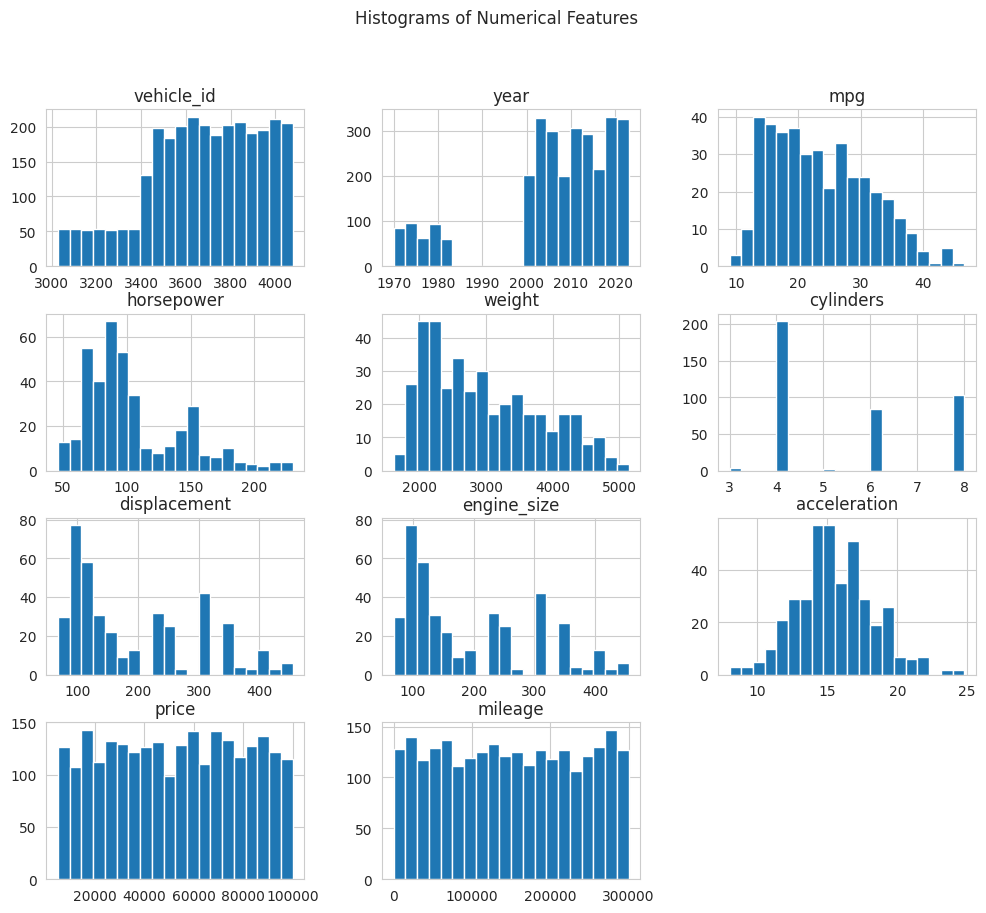

In [ ]:
# Histograms of Numerical Features of my csv
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.show()

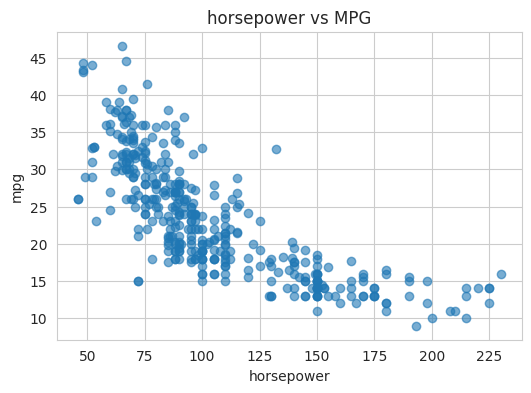

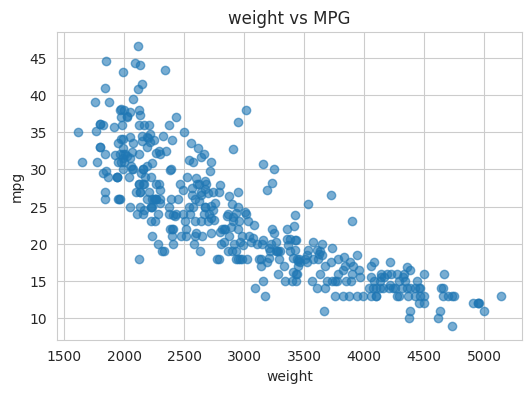

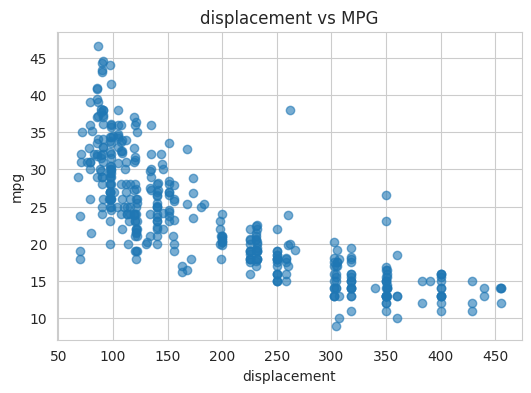

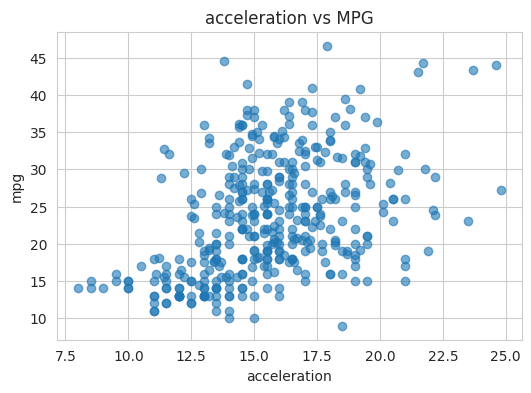

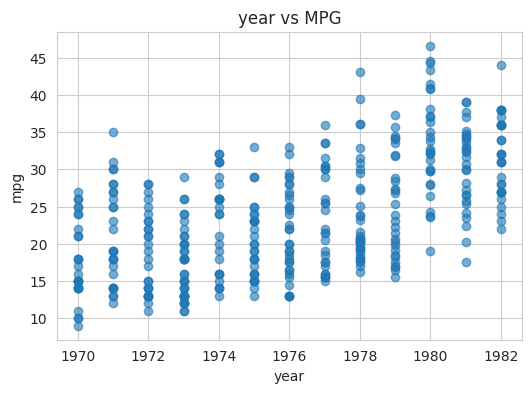

In [ ]:
# Show correlation of features to target variable mpg
features = ['horsepower', 'weight', 'displacement', 'acceleration', 'year']

for col in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df['mpg'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('mpg')
    plt.title(f'{col} vs MPG')
    plt.show()

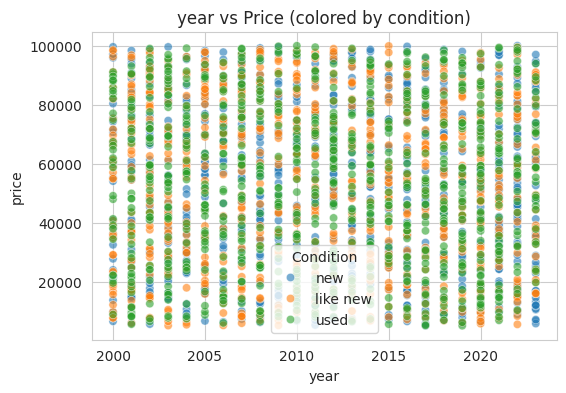

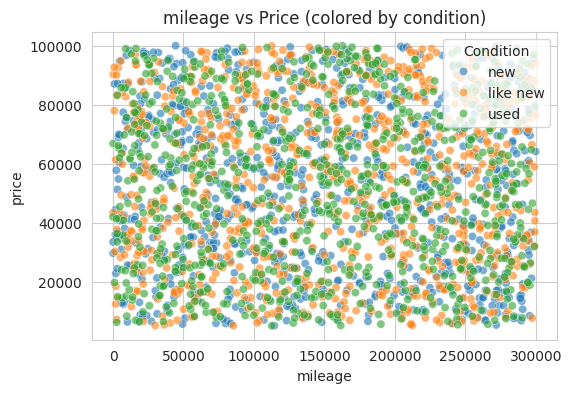

In [ ]:
# Show correlation of features to target variable price
features = ['year', 'mileage']

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['price'], hue=df['condition_name'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('price')
    plt.title(f'{col} vs Price (colored by condition)')
    plt.legend(title="Condition")
    plt.show()

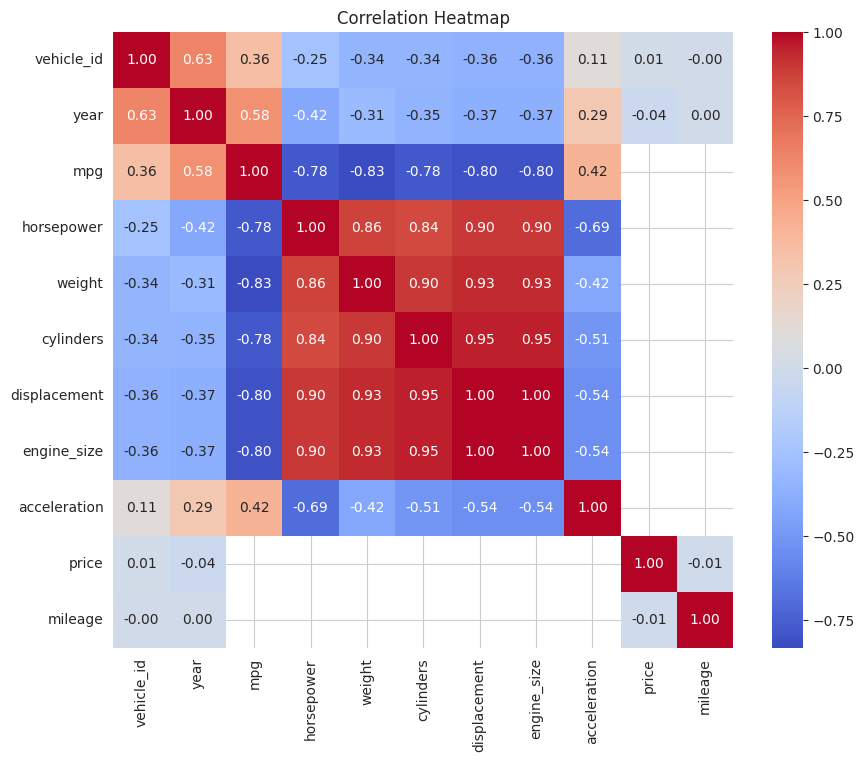

In [ ]:
# Cool heatmap to visualize correlation of features on each other.

plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

###For my project, there are two target variables: MPG and Price. First, I will do predict price, using linear regression.

The code below will complete data processing, it will train the model, it will run predictions, and will graph the results.

BEST PARAMETERS: {'regressor__fit_intercept': False}
BEST CV SCORE: -0.023502261086676857
PRICE MODEL
MAE: 22925.900934172892
MSE: 707487143.3670758
RMSE: 26598.630479163316
R^2: -0.005055565259676875


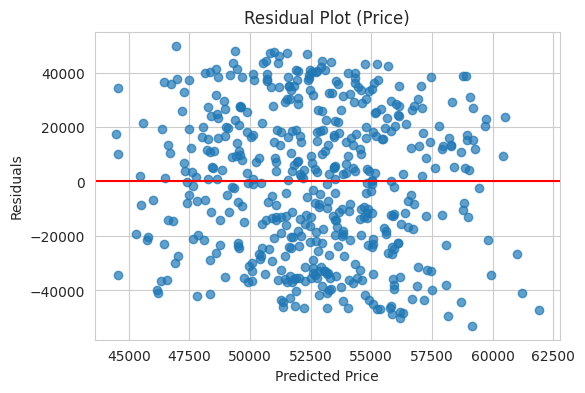

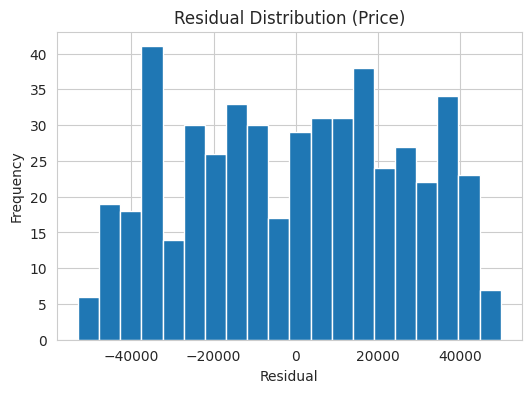

In [ ]:
price_data = df.dropna(subset=['price']).copy()

# Drop MPG-related columns that are empty
X_price = price_data.drop(columns=[
    'price',
    'mpg',
    'horsepower',
    'weight',
    'cylinders',
    'displacement',
    'engine_size',
    'acceleration',
    'origin_name'
], errors='ignore')

# Target Feature
y_price = price_data['price']

numeric_cols = X_price.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_price.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_price = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

price_pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_price),
    ('regressor', LinearRegression())
])

param_grid_price_lr = {
    'regressor__fit_intercept': [True, False]
}

grid_price_lr = GridSearchCV(
    estimator=price_pipeline_lr,
    param_grid=param_grid_price_lr,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_price_lr.fit(X_train_price, y_train_price)

best_price_lr = grid_price_lr.best_estimator_
y_pred_price = best_price_lr.predict(X_test_price)

print("BEST PARAMETERS:", grid_price_lr.best_params_)
print("BEST CV SCORE:", grid_price_lr.best_score_)

print("PRICE MODEL")
print("MAE:", mean_absolute_error(y_test_price, y_pred_price))
print("MSE:", mean_squared_error(y_test_price, y_pred_price))
print("RMSE:", np.sqrt(mean_squared_error(y_test_price, y_pred_price)))
print("R^2:", r2_score(y_test_price, y_pred_price))

#print("Mean R^2 for 5 folds:", cv_price_results['test_r2'].mean())

#rmse_price = np.sqrt(-cv_price_results['test_neg_mean_squared_error'])
#print("Mean RMSE:", rmse_price.mean())


residuals = y_test_price - y_pred_price

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred_price, residuals, alpha=0.7)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (Price)")
plt.show()

# Residual distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (Price)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

Predict MPG with linear regression

TUNED MPG LINEAR REGRESSION
BEST PARAMETERS: {'regressor__fit_intercept': True}
BEST CV SCORE: 0.4319723000408775
MAE: 2.4151292034666922
MSE: 9.400835320446737
RMSE: 3.066078166069276
R^2: 0.8139925231055446


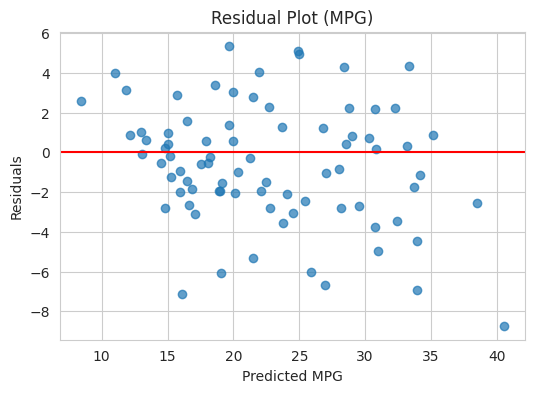

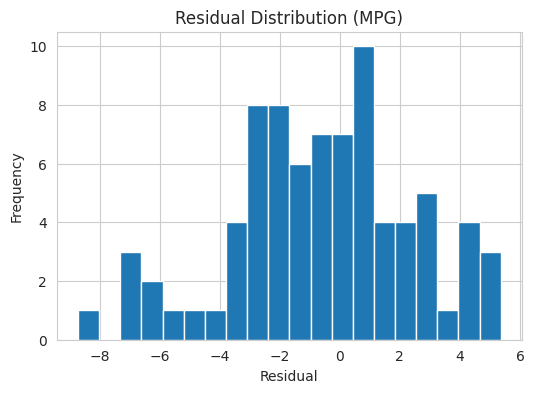

In [ ]:
mpg_data = df.dropna(subset=['mpg']).copy()

X_mpg = mpg_data.drop(columns=[
    'mpg',
    'price',
    'mileage',
    'condition_name'
], errors='ignore')

# Target Feature
y_mpg = mpg_data['mpg']

numeric_cols = X_mpg.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_mpg.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_mpg = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_mpg, X_test_mpg, y_train_mpg, y_test_mpg = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

mpg_pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_mpg),
    ('regressor', LinearRegression())
])

param_grid_mpg_lr = {
    'regressor__fit_intercept': [True, False]
}

grid_mpg_lr = GridSearchCV(
    estimator=mpg_pipeline_lr,
    param_grid=param_grid_mpg_lr,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_mpg_lr.fit(X_train_mpg, y_train_mpg)

best_mpg_lr = grid_mpg_lr.best_estimator_
y_pred_mpg = best_mpg_lr.predict(X_test_mpg)

print("TUNED MPG LINEAR REGRESSION")
print("BEST PARAMETERS:", grid_mpg_lr.best_params_)
print("BEST CV SCORE:", grid_mpg_lr.best_score_)
print("MAE:", mean_absolute_error(y_test_mpg, y_pred_mpg))
print("MSE:", mean_squared_error(y_test_mpg, y_pred_mpg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_mpg, y_pred_mpg)))
print("R^2:", r2_score(y_test_mpg, y_pred_mpg))

residuals = y_test_mpg - y_pred_mpg

plt.figure(figsize=(6,4))
plt.scatter(y_pred_mpg, residuals, alpha=0.7)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot (MPG)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (MPG)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

Price with Nueral net (MLPRegressor)

TUNED PRICE MLP MODEL
BEST PARAMETERS: {'regressor__activation': 'relu', 'regressor__alpha': 0.01, 'regressor__hidden_layer_sizes': (16, 8), 'regressor__learning_rate_init': 0.001}
BEST CV SCORE: -0.005938967385051885
MAE: 22919.89905177792
MSE: 704497150.686152
RMSE: 26542.365205198876
R^2: -0.0008079844912882717


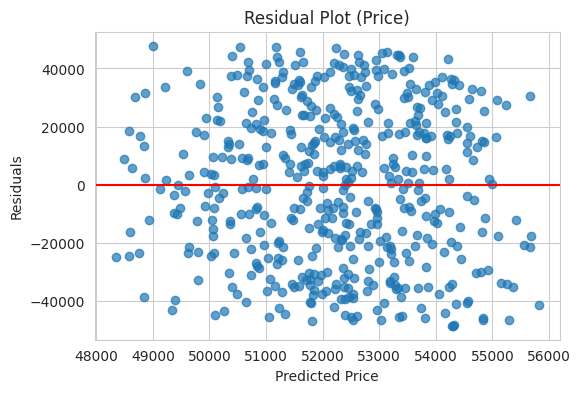

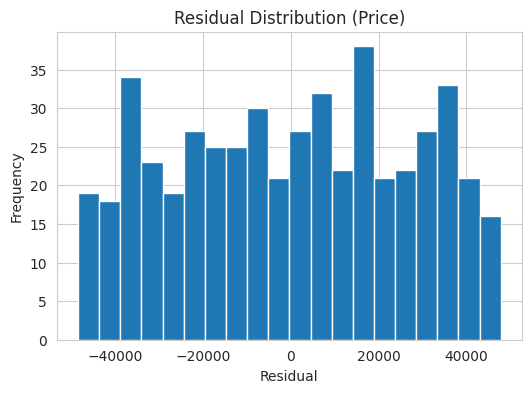

In [ ]:
price_data = df.dropna(subset=['price']).copy()

X_price = price_data.drop(columns=[
    'price',
    'mpg',
    'horsepower',
    'weight',
    'cylinders',
    'displacement',
    'engine_size',
    'acceleration',
    'origin_name'
], errors='ignore')

# Target Feature
y_price = price_data['price']

numeric_cols = X_price.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_price.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_price = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

price_pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor_price),
    ('regressor', MLPRegressor(
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

param_grid_price_mlp = {
    'regressor__hidden_layer_sizes': [(16,), (32,), (16, 8), (32, 16)],
    'regressor__activation': ['relu', 'tanh'],
    'regressor__alpha': [0.0001, 0.001, 0.01],
    'regressor__learning_rate_init': [0.0005, 0.001]
}

grid_price_mlp = GridSearchCV(
    estimator=price_pipeline_mlp,
    param_grid=param_grid_price_mlp,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_price_mlp.fit(X_train_price, y_train_price)

best_price_mlp = grid_price_mlp.best_estimator_
y_pred_price = best_price_mlp.predict(X_test_price)

print("TUNED PRICE MLP MODEL")
print("BEST PARAMETERS:", grid_price_mlp.best_params_)
print("BEST CV SCORE:", grid_price_mlp.best_score_)
print("MAE:", mean_absolute_error(y_test_price, y_pred_price))
print("MSE:", mean_squared_error(y_test_price, y_pred_price))
print("RMSE:", np.sqrt(mean_squared_error(y_test_price, y_pred_price)))
print("R^2:", r2_score(y_test_price, y_pred_price))


residuals = y_test_price - y_pred_price

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred_price, residuals, alpha=0.7)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (Price)")
plt.show()

# Residual distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (Price)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

MPG with MLPregressor

TUNED MPG MLP MODEL
BEST PARAMETERS: {'regressor__activation': 'relu', 'regressor__alpha': 0.0001, 'regressor__hidden_layer_sizes': (32, 16), 'regressor__learning_rate_init': 0.001}
BEST CV SCORE: 0.7597563708526384
MAE: 2.6574758925948823
MSE: 12.36563181637798
RMSE: 3.516480032131276
R^2: 0.7553302556670074


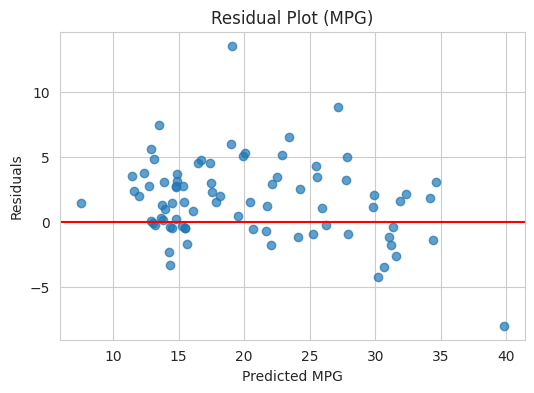

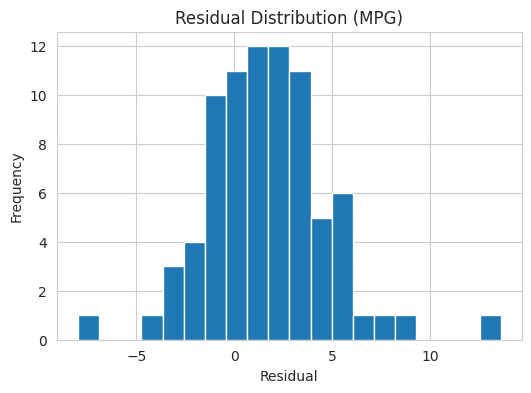

In [ ]:
mpg_data = df.dropna(subset=['mpg']).copy()

X_mpg = mpg_data.drop(columns=[
    'mpg',
    'price',
    'mileage',
    'condition_name'
], errors='ignore')

# Target Feature
y_mpg = mpg_data['mpg']

numeric_cols = X_mpg.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_mpg.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_mpg = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_mpg, X_test_mpg, y_train_mpg, y_test_mpg = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

mpg_pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor_mpg),
    ('regressor', MLPRegressor(
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

param_grid_mpg_mlp = {
    'regressor__hidden_layer_sizes': [(16,), (32,), (16, 8), (32, 16)],
    'regressor__activation': ['relu', 'tanh'],
    'regressor__alpha': [0.0001, 0.001, 0.01],
    'regressor__learning_rate_init': [0.0005, 0.001]
}

grid_mpg_mlp = GridSearchCV(
    estimator=mpg_pipeline_mlp,
    param_grid=param_grid_mpg_mlp,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_mpg_mlp.fit(X_train_mpg, y_train_mpg)

best_mpg_mlp = grid_mpg_mlp.best_estimator_
y_pred_mpg = best_mpg_mlp.predict(X_test_mpg)

print("TUNED MPG MLP MODEL")
print("BEST PARAMETERS:", grid_mpg_mlp.best_params_)
print("BEST CV SCORE:", grid_mpg_mlp.best_score_)
print("MAE:", mean_absolute_error(y_test_mpg, y_pred_mpg))
print("MSE:", mean_squared_error(y_test_mpg, y_pred_mpg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_mpg, y_pred_mpg)))
print("R^2:", r2_score(y_test_mpg, y_pred_mpg))



residuals = y_test_mpg - y_pred_mpg

plt.figure(figsize=(6,4))
plt.scatter(y_pred_mpg, residuals, alpha=0.7)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot (MPG)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (MPG)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

Price with decision Trees

TUNED PRICE DECISION TREE MODEL
BEST PARAMETERS: {'regressor__max_depth': 3, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}
BEST CV SCORE: -0.02391451253909538
MAE: 22907.53904848135
MSE: 705868284.8666344
RMSE: 26568.181813338946
R^2: -0.0027558164084211523


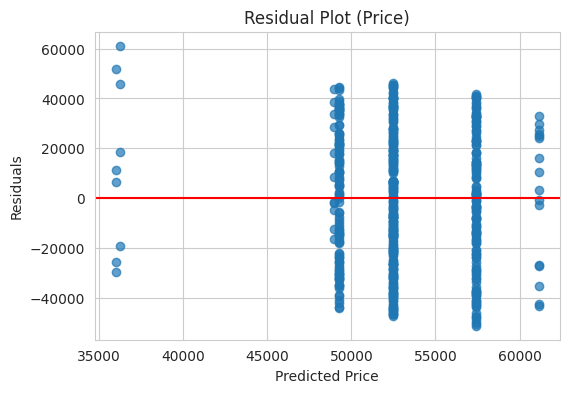

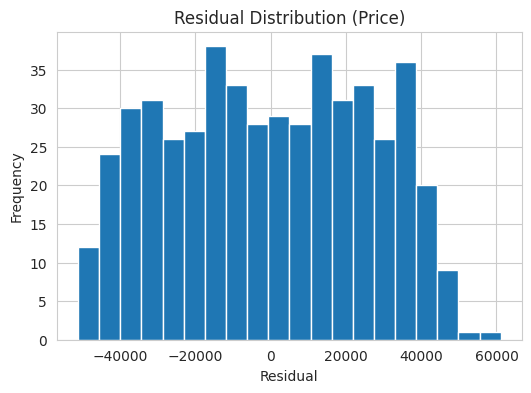

In [ ]:
price_data = df.dropna(subset=['price']).copy()

X_price = price_data.drop(columns=[
    'price',
    'mpg',
    'horsepower',
    'weight',
    'cylinders',
    'displacement',
    'engine_size',
    'acceleration',
    'origin_name'
], errors='ignore')

# Target Feature
y_price = price_data['price']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_price = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

price_pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor_price),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid_price_dt = {
    'regressor__max_depth': [3, 5, 7, 10, None],
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 5, 10]
}

grid_price_dt = GridSearchCV(
    estimator=price_pipeline_dt,
    param_grid=param_grid_price_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_price_dt.fit(X_train_price, y_train_price)

best_price_dt = grid_price_dt.best_estimator_
y_pred_price = best_price_dt.predict(X_test_price)

print("TUNED PRICE DECISION TREE MODEL")
print("BEST PARAMETERS:", grid_price_dt.best_params_)
print("BEST CV SCORE:", grid_price_dt.best_score_)
print("MAE:", mean_absolute_error(y_test_price, y_pred_price))
print("MSE:", mean_squared_error(y_test_price, y_pred_price))
print("RMSE:", np.sqrt(mean_squared_error(y_test_price, y_pred_price)))
print("R^2:", r2_score(y_test_price, y_pred_price))


residuals = y_test_price - y_pred_price

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred_price, residuals, alpha=0.7)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (Price)")
plt.show()

# Residual distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (Price)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

MPG with Decision Trees

TUNED MPG DECISION TREE MODEL
BEST PARAMETERS: {'regressor__max_depth': 7, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 2}
BEST CV SCORE: 0.7911186270881732
MAE: 2.1077281468531472
MSE: 9.668402222917761
RMSE: 3.1094054452447595
R^2: 0.8086983718165786


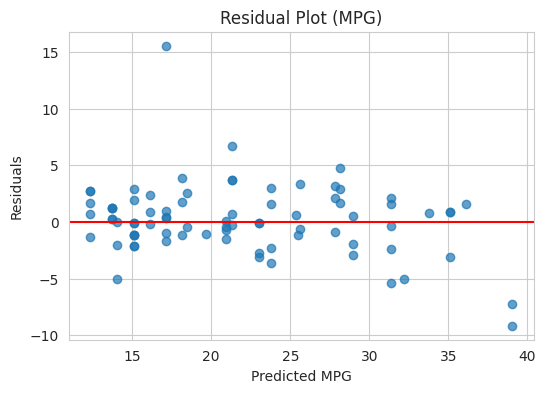

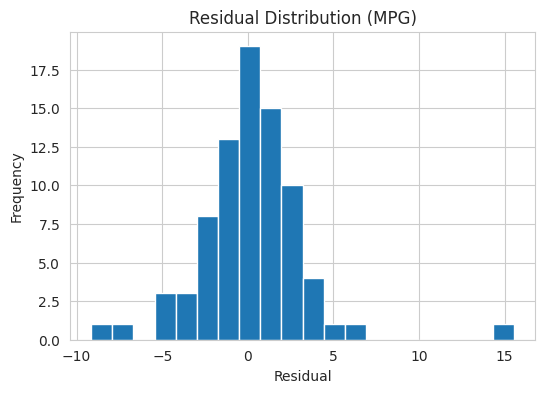

In [ ]:
mpg_data = df.dropna(subset=['mpg']).copy()

X_mpg = mpg_data.drop(columns=[
    'mpg',
    'price',
    'mileage',
    'condition_name'
], errors='ignore')

# Target Feature
y_mpg = mpg_data['mpg']

numeric_cols = X_mpg.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_mpg.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_mpg = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_mpg, X_test_mpg, y_train_mpg, y_test_mpg = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

mpg_pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor_mpg),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid_mpg_dt = {
    'regressor__max_depth': [3, 5, 7, 10, None],
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 5, 10]
}

grid_mpg_dt = GridSearchCV(
    estimator=mpg_pipeline_dt,
    param_grid=param_grid_mpg_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_mpg_dt.fit(X_train_mpg, y_train_mpg)

best_mpg_dt = grid_mpg_dt.best_estimator_
y_pred_mpg = best_mpg_dt.predict(X_test_mpg)

print("TUNED MPG DECISION TREE MODEL")
print("BEST PARAMETERS:", grid_mpg_dt.best_params_)
print("BEST CV SCORE:", grid_mpg_dt.best_score_)
print("MAE:", mean_absolute_error(y_test_mpg, y_pred_mpg))
print("MSE:", mean_squared_error(y_test_mpg, y_pred_mpg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_mpg, y_pred_mpg)))
print("R^2:", r2_score(y_test_mpg, y_pred_mpg))

residuals = y_test_mpg - y_pred_mpg

plt.figure(figsize=(6,4))
plt.scatter(y_pred_mpg, residuals, alpha=0.7)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot (MPG)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (MPG)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()



#PLOTS!!!

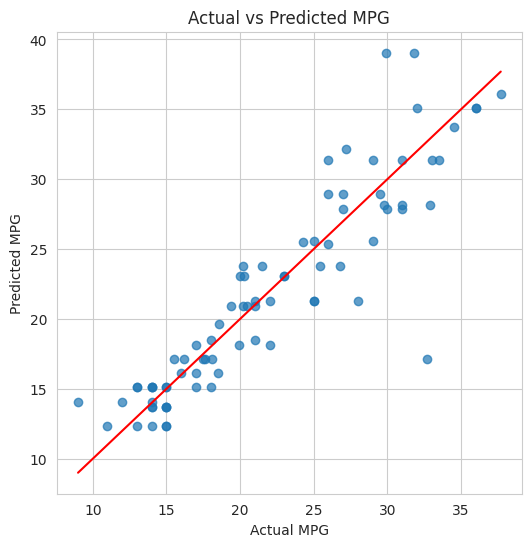

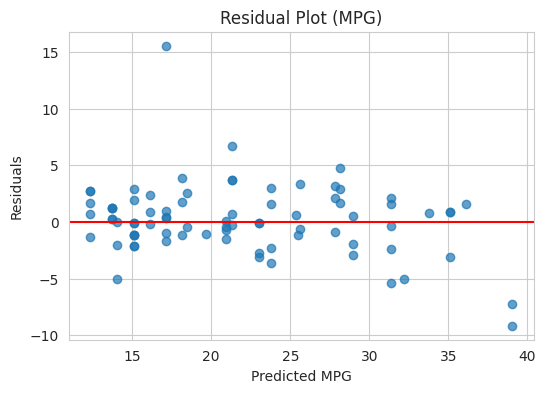

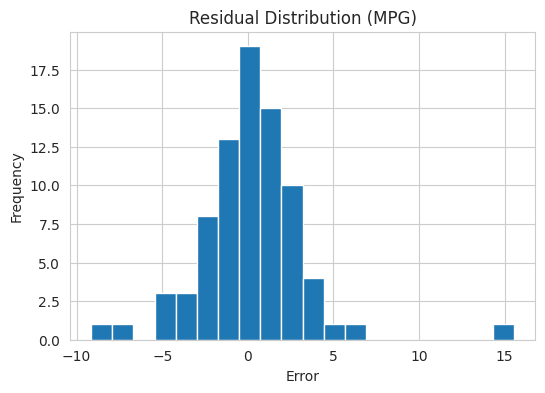

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_mpg, y_pred_mpg, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

# ideal line
plt.plot([y_test_mpg.min(), y_test_mpg.max()],
         [y_test_mpg.min(), y_test_mpg.max()],
         color='red')

plt.show()

residuals = y_test_mpg - y_pred_mpg

plt.figure(figsize=(6,4))
plt.scatter(y_pred_mpg, residuals, alpha=0.7)
plt.axhline(y=0, color='red')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot (MPG)")

plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)

plt.title("Residual Distribution (MPG)")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

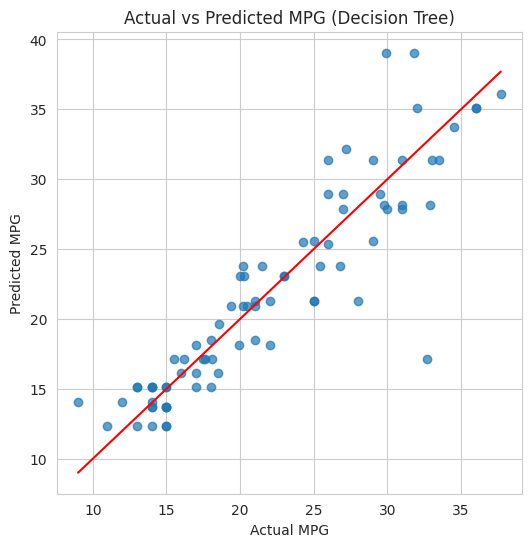

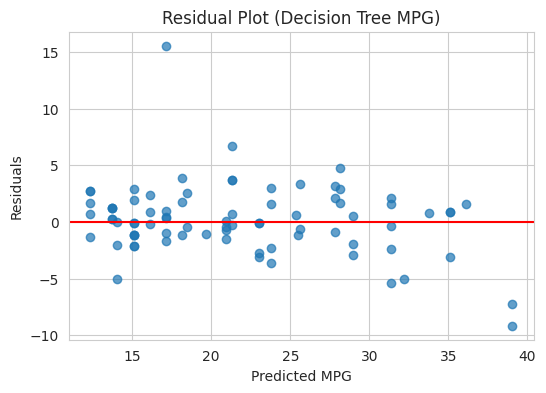

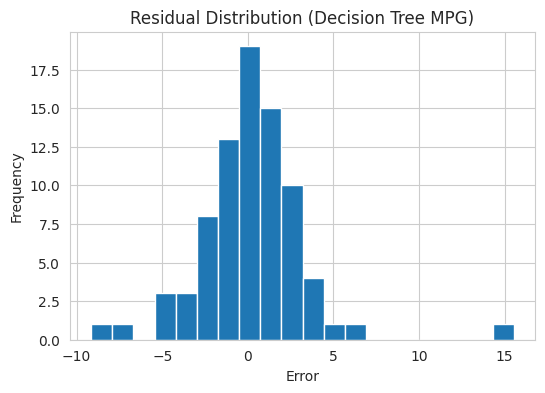

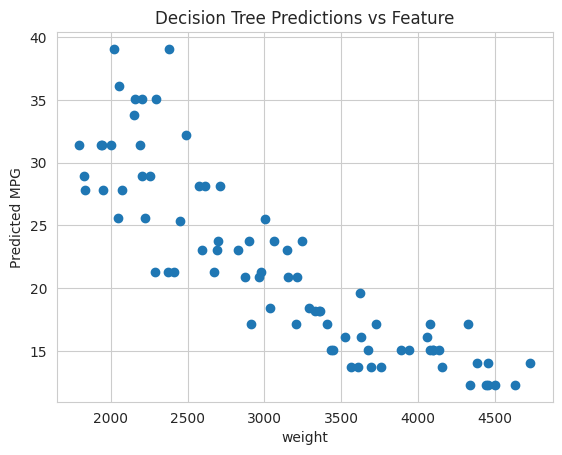

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_mpg, y_pred_mpg, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (Decision Tree)")

# Ideal prediction line
plt.plot([y_test_mpg.min(), y_test_mpg.max()],
         [y_test_mpg.min(), y_test_mpg.max()],
         color='red')

plt.show()

residuals = y_test_mpg - y_pred_mpg

plt.figure(figsize=(6,4))
plt.scatter(y_pred_mpg, residuals, alpha=0.7)
plt.axhline(y=0, color='red')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot (Decision Tree MPG)")

plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)

plt.title("Residual Distribution (Decision Tree MPG)")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

#

feature = 'weight'  # or horsepower

plt.scatter(X_test_mpg[feature], y_pred_mpg)
plt.xlabel(feature)
plt.ylabel("Predicted MPG")
plt.title("Decision Tree Predictions vs Feature")
plt.show()

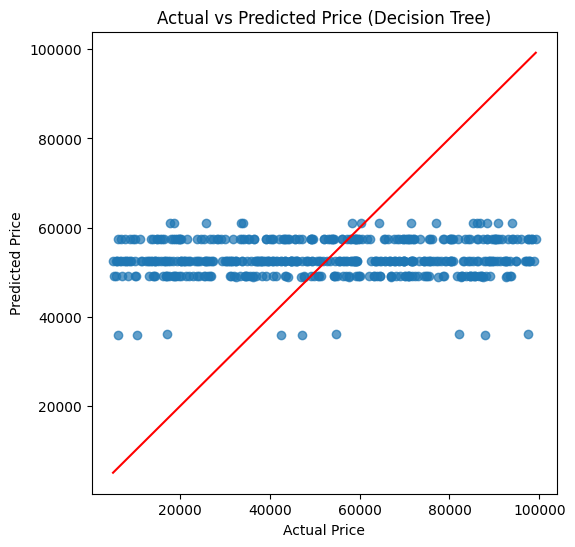

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_price, y_pred_price, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Decision Tree)")

plt.plot([y_test_price.min(), y_test_price.max()],
         [y_test_price.min(), y_test_price.max()],
         color='red')

plt.show()

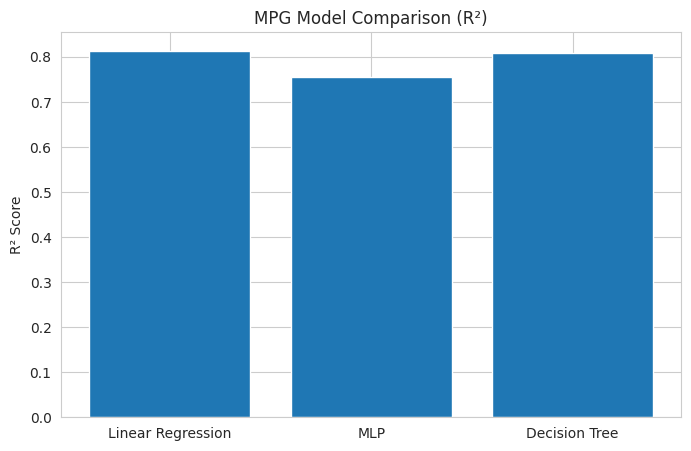

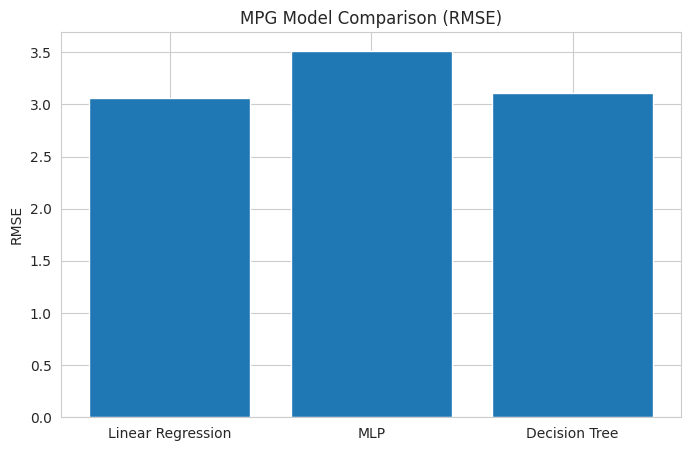

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'MLP', 'Decision Tree']
r2_scores = [0.8139925231055446, 0.7553302556670074, 0.8086983718165786]
rmse_scores = [3.066078166069276, 3.516480032131276, 3.1094054452447595]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.title("MPG Model Comparison (R²)")
plt.ylabel("R² Score")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)
plt.title("MPG Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

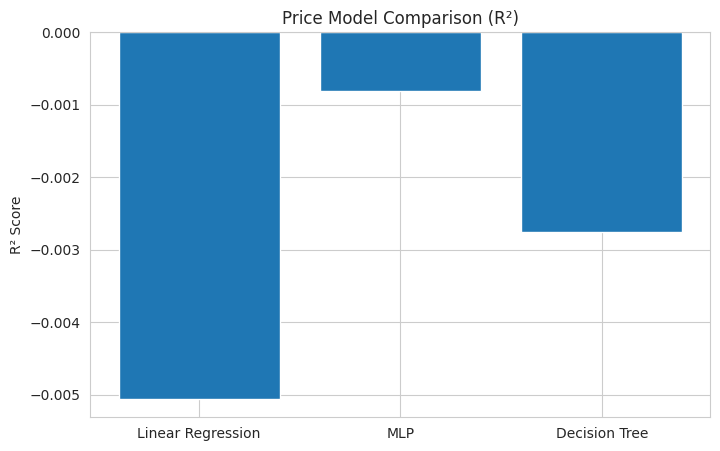

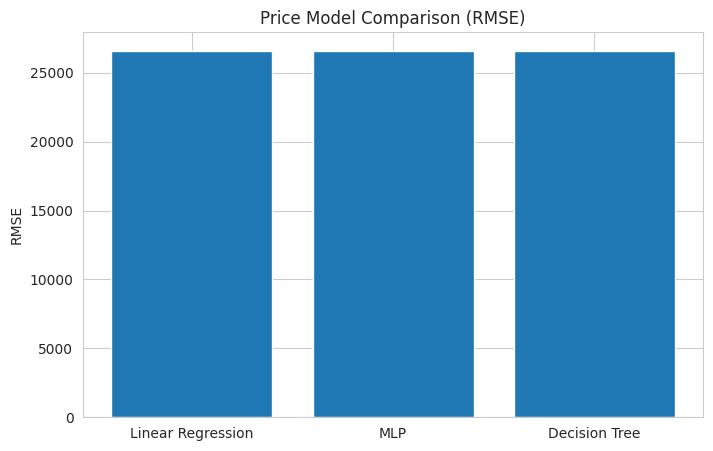

In [ ]:
models = ['Linear Regression', 'MLP', 'Decision Tree']
r2_scores = [-0.005055565259676875, -0.0008079844912882717, -0.0027558164084211523]
rmse_scores = [26598.630479163316, 26542.365205198876, 26568.181813338946]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.title("Price Model Comparison (R²)")
plt.ylabel("R² Score")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)
plt.title("Price Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

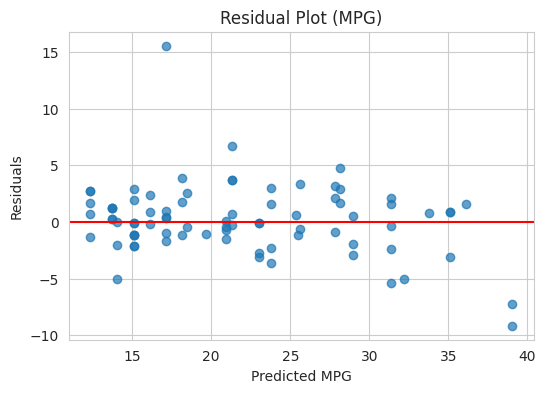

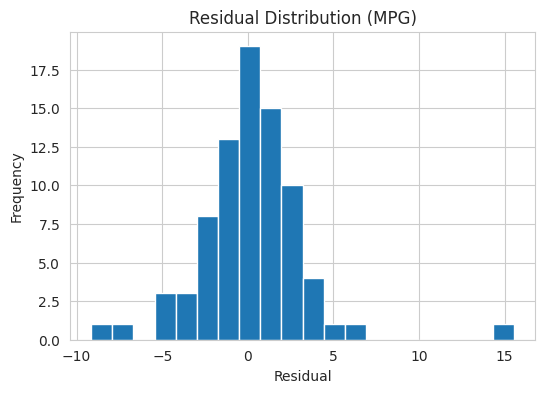

In [ ]:

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (MPG)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()